# 01 - Data Ingestion

Runs the ingestion pipeline (`pricelab.ingest`) and inspects the tidy-long
master table it produces.

**Pipeline stage:** Data Collection -> Integration -> (light) Cleaning.
Later notebooks cover EDA, factor identification, forecasting, and decision support.

In [1]:
# --- environment bootstrap (works locally and on Google Colab) ---
import os, sys, subprocess

try:
    import pricelab  # noqa: F401
except ImportError:
    # On Colab: mount Drive and point PRICELAB_DATA_DIR at your data folder.
    if "google.colab" in sys.modules:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT = "/content/drive/MyDrive/price-trend-framework"
        os.environ["PRICELAB_DATA_DIR"] = f"{PROJECT}/data"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", PROJECT], check=True)
    else:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".."], check=True)
    import pricelab

print("pricelab", pricelab.__version__)
print("data dir:", pricelab.data_dir())

pricelab 0.1.0
data dir: C:\Users\Isma Tahira\price-trend-framework\data


In [2]:
from pricelab.ingest import run

result = run(all=True, write=True)
master = result.master
master.head()

,date,freq,region,region_level,commodity,variable,value,unit,source,is_imputed
0,2016-07-01,M,Pakistan,national,Alcoholic Beverages & Tobacco,cpi_index,107.65,index_2015_16=100,inflation_cpi_groups,False
1,2016-07-01,M,Pakistan,national,Clothing & Footwear,cpi_index,103.48,index_2015_16=100,inflation_cpi_groups,False
2,2016-07-01,M,Pakistan,national,Communication,cpi_index,99.86,index_2015_16=100,inflation_cpi_groups,False
3,2016-07-01,M,Pakistan,national,Education,cpi_index,105.77,index_2015_16=100,inflation_cpi_groups,False
4,2016-07-01,M,Pakistan,national,Food & Non-Alcoholic Beverages,cpi_index,104.28,index_2015_16=100,inflation_cpi_groups,False


In [3]:
# rows by source and variable
master.groupby(["source", "variable"]).size()

source                variable       
crop_production       crop_area          1940
                      crop_production    1940
                      crop_yield         1939
inflation_cpi_groups  cpi_index          1573
dtype: int64

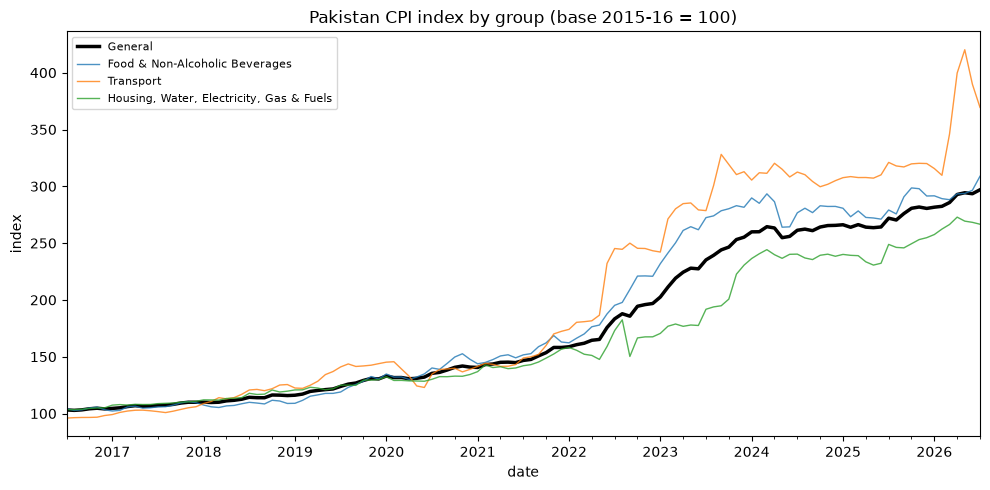

In [4]:
import matplotlib.pyplot as plt

cpi = master[(master.source == "inflation_cpi_groups")]
wide = cpi.pivot_table(index="date", columns="commodity", values="value")

fig, ax = plt.subplots(figsize=(10, 5))
wide["General"].plot(ax=ax, lw=2.5, color="black", label="General")
for col in ["Food & Non-Alcoholic Beverages", "Transport", "Housing, Water, Electricity, Gas & Fuels"]:
    if col in wide:
        wide[col].plot(ax=ax, lw=1, alpha=0.8, label=col)
ax.set_title("Pakistan CPI index by group (base 2015-16 = 100)")
ax.set_ylabel("index")
ax.legend(fontsize=8)
plt.tight_layout()

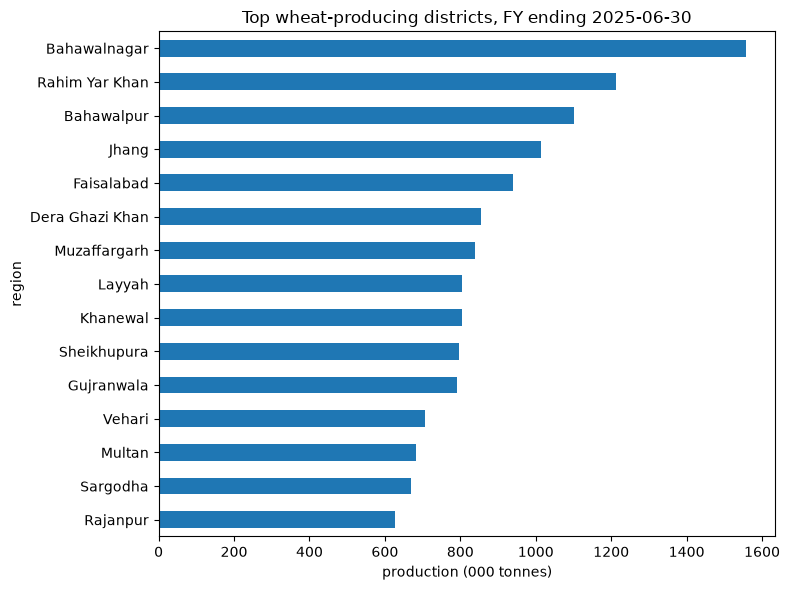

In [5]:
# latest year of district wheat production (annual crop panel)
crops = master[master.variable == "crop_production"]
wheat = crops[crops.commodity == "Wheat"]
latest = wheat[wheat.date == wheat.date.max()].nlargest(15, "value")

ax = latest.set_index("region")["value"].sort_values().plot.barh(figsize=(8, 6))
ax.set_title(f"Top wheat-producing districts, FY ending {wheat.date.max().date()}")
ax.set_xlabel("production (000 tonnes)")
plt.tight_layout()

In [6]:
print((pricelab.data_dir() / "processed" / "ingestion_report.md").read_text(encoding="utf-8"))

# Ingestion report

_generated 2026-08-30 19:54_

## Summary

- fact sources: **2**
- dimension tables: **3**
- master_long rows: **7392**
- duplicate rows dropped: **0**

## Coverage

| source | variable | rows | date min | date max | freq | regions | imputed |
|---|---|--:|---|---|---|--:|--:|
| crop_production | crop_area | 1940 | 2021-06-30 | 2025-06-30 | A | 122 | 0 |
| crop_production | crop_production | 1940 | 2021-06-30 | 2025-06-30 | A | 122 | 0 |
| crop_production | crop_yield | 1939 | 2021-06-30 | 2025-06-30 | A | 122 | 1939 |
| inflation_cpi_groups | cpi_index | 1573 | 2016-07-01 | 2026-07-01 | M | 1 | 0 |

## Null values in `value` (post-load)

| source | null values |
|---|--:|
| crop_production | 0 |
| inflation_cpi_groups | 0 |

## Dimension tables

| table | rows | columns |
|---|--:|---|
| crop_dim | 125 | id, name, Type |
| region_hierarchy | 156 | pvid, dvid, dsid, ds, dv, pv |
| cpi_item_dictionary | 356 | SrNo, ImageID, ItemCode, Commodity, DescriptionLong, Unit |